# Blackbox Optimisation Project: Week Two


Unlike week 1, I considered the output-input relationship this week. I still explore the sample space by looking for a "most isolated point", but this time I maunally define a bounding box for that search based on observations from the input-output relationships  <br><br> -- functionality was added to scatter the output "Y1" as a function of each input variable independently  <br> -- where clear trends were present, I used the bounding box to exclude regions of the domain where a maximum looked highly unlikely 

In [1]:
week = 7

Import Standard Libraries

In [2]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path

import matplotlib.pyplot as plt

Import Project Packages

In [3]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

#### Import data and create output directories

In [4]:
function = 1

In [5]:
# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)
print(f"Requested function {function} in week {week}")

Requested function 1 in week 7


In [6]:
# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"results will be saved to {results_dir}")

results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_7\function_1


In [7]:
# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)


Loaded initial data: function_1


In [8]:
# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)


Available update files:
1: new_data_point_wk1.csv
2: new_data_point_wk2.csv
3: new_data_point_wk3.csv
4: new_data_point_wk4.csv
5: new_data_point_wk5.csv
6: new_data_point_wk6.csv
Added 6 new data points.


#### Augment data set

In [9]:
# separate inputs from outputs
input_cols = data_loading.get_X_cols(df)

In [10]:
# Scale the outputs
df["YScaled"] = data_augmentation.minmax_scale(df["Y1"])

In [11]:
df_inputs = df[input_cols]
df_output = df["YScaled"]

Find most isolated point in the input space, bound by a user defined bounding box

In [12]:
X = df_inputs.to_numpy()
df_box, bounds_info = data_augmentation.compute_hypercube_corners(X)

# df_masked = data_augmentation.filter_points_in_bounding_box(df_inputs, bounds_info)
# df_box = pd.concat([df_box, df_masked], ignore_index=True)

In [13]:
hull_box, points_box = data_augmentation.compute_convex_hull(df_box)

In [14]:
points = df_inputs.to_numpy()

best_point, best_dist = data_augmentation.most_isolated_point_new(points, hull_box, n_samples=10000, seed=42,bounds=bounds_info)

def to_dict(point, columns):
    return {col: val for col, val in zip(columns, point)}

best_point_dict = to_dict(best_point, input_cols)

In [15]:
bounds_info

{'lowers': array([0.05, 0.05]),
 'uppers': array([0.95, 0.95]),
 'corners':      X1    X2
 0  0.05  0.05
 1  0.05  0.95
 2  0.95  0.05
 3  0.95  0.95}

#### Plot Results

In [16]:
# points = df_inputs.to_numpy()
new_point_flag = df["new data point"].to_numpy()

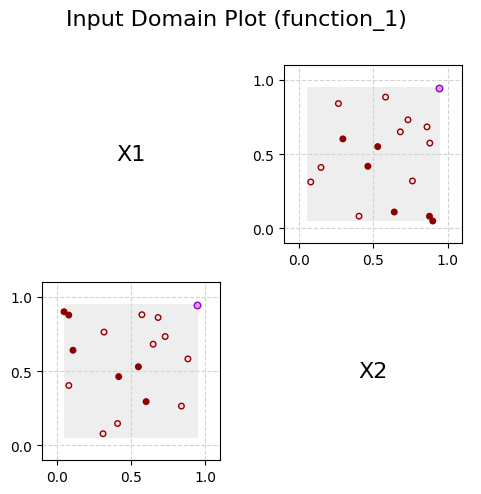

In [17]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points_box, new_point_flag, hull = hull_box, next_point = best_point_dict)

In [18]:
X = df_inputs.to_numpy()
Y = df_output.to_numpy()

Y = np.asarray(Y).reshape(-1, 1)

(<Figure size 500x250 with 2 Axes>,
 array([[<Axes: xlabel='X1', ylabel='Y1'>, <Axes: xlabel='X2'>]],
       dtype=object))

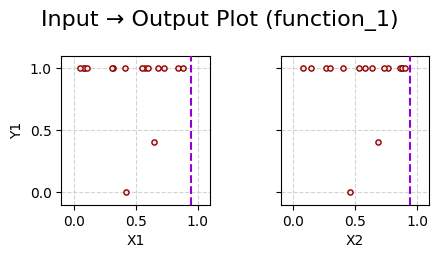

In [19]:
data_plotting.domain_io_plot(data_folder_name,results_dir,input_cols,["Y1"],X,Y,next_point=best_point_dict)

#### write next point to csv

In [20]:
data_loading.append_results(results_dir, data_folder_name, best_point_dict)

In [21]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.945974-0.944914
